<a href="https://colab.research.google.com/github/h-muhammed/bank-churn-ml-classification/blob/main/notebooks/02_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Customer Churn Prediction
This notebook implements a Random Forest Classifier to predict customer churn based on the UCI Bank Marketing dataset.

### Step 1: Data Setup
We initialize the environment and load the raw data.

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset Column Descriptions

Based on the provided datasets, here is a short breakdown of the columns:

### **Columns in `X_test.csv` and `X_train.csv` (Features)**
These are the input variables used to predict customer behavior. They have been standardized (scaled).

*   **CreditScore:** The customer's creditworthiness.
*   **Gender:** Binary representation of the customer's gender.
*   **Age:** The age of the customer.
*   **Tenure:** Number of years the customer has been with the bank.
*   **Balance:** The amount of money in the customer's account.
*   **NumOfProducts:** How many bank products (e.g., savings account, credit card) the customer uses.
*   **HasCrCard:** Whether the customer has a credit card.
*   **IsActiveMember:** Whether the customer is an active user of bank services.
*   **EstimatedSalary:** The estimated annual income of the customer.
*   **Geography_France / Germany / Spain:** One-hot encoded columns indicating the customer's country.

### **Columns in `y_test.csv` and `y_train.csv` (Target)**
This is the outcome the model is trying to predict.

*   **Exited:** The target variable.
    *   **1:** The customer left the bank (Churn).
    *   **0:** The customer stayed with the bank.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
import joblib
import os

# Define the path to the preprocessed data in Google Drive
data_path = '/content/drive/MyDrive/bank-churn-dataset/data'

# Load preprocessed data (corrected filenames to lowercase 'x')
X_train = pd.read_csv(os.path.join(data_path, 'x_train.csv'))
X_test  = pd.read_csv(os.path.join(data_path, 'x_test.csv'))
y_train = pd.read_csv(os.path.join(data_path, 'y_train.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(data_path, 'y_test.csv')).squeeze()

# For compatibility with downstream cells that might expect a full X and y for column names or overall distribution
X = X_train.copy() # Using X_train as a representation for X
y = pd.concat([y_train, y_test], ignore_index=True)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Overall churn rate (combined train and test): {y.mean()*100:.1f}%")

display(X_train.head())
display(y_train.head())

X_train shape: (8000, 12)
X_test shape:  (2000, 12)
y_train shape: (8000,)
y_test shape:  (2000,)
Overall churn rate (combined train and test): 20.4%


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,1.058568,0.907507,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,1.001752,-0.578313,-0.577735
1,0.913626,0.907507,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,-0.998252,1.729169,-0.577735
2,1.079274,-1.101919,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,-0.998252,1.729169,-0.577735
3,-0.929207,0.907507,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,1.001752,-0.578313,-0.577735
4,0.427035,0.907507,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,-0.998252,1.729169,-0.577735


,Exited
0,1
1,1
2,0
3,0
4,0


### Step 2: Data Preprocessing (Skipped)
This step is now skipped as the data (`X_train`, `X_test`, `y_train`, `y_test`) is already preprocessed and loaded.

In [73]:
# The data is already preprocessed and split into X_train, X_test, y_train, y_test.
# No further preprocessing steps are required here.
print("Data preprocessing step skipped as data is already preprocessed.")
print(f"Number of features in X_train: {X_train.shape[1]}")

Data preprocessing step skipped as data is already preprocessed.
Number of features in X_train: 12


### Step 3: Model Implementation & Training
Training the Random Forest with balanced class weights.

In [74]:
rf_model = RandomForestClassifier(
    n_estimators=200,  # Increased from 100
    max_depth=15,      # Increased from 10
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


### Step 4: Model Evaluation
Calculating Accuracy, F1, and AUC.

In [75]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

Accuracy: 0.8570
F1 Score: 0.6061
ROC-AUC: 0.8573


### Step 5: Visualization and Threshold Tuning
Plotting performance metrics and finding an optimal threshold for recall.

Top 10 Feature Importances:
Age                  0.269225
NumOfProducts        0.151309
Balance              0.137892
EstimatedSalary      0.122376
CreditScore          0.118291
Tenure               0.070781
IsActiveMember       0.039999
Geography_Germany    0.029807
Gender               0.021174
HasCrCard            0.015679
dtype: float64

Classification Report (default 0.5 threshold):
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1593
           1       0.69      0.54      0.61       407

    accuracy                           0.86      2000
   macro avg       0.79      0.74      0.76      2000
weighted avg       0.85      0.86      0.85      2000



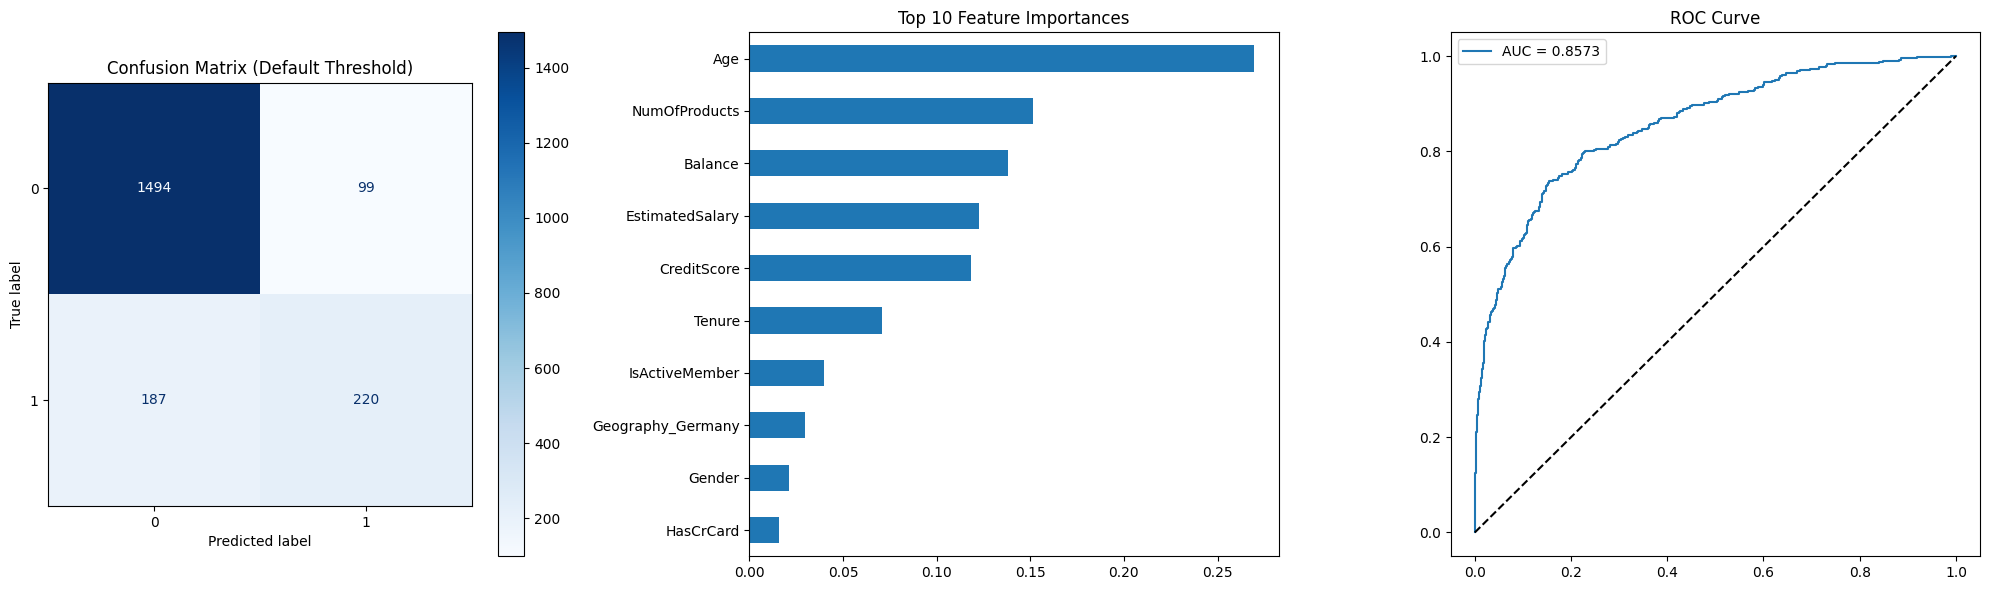

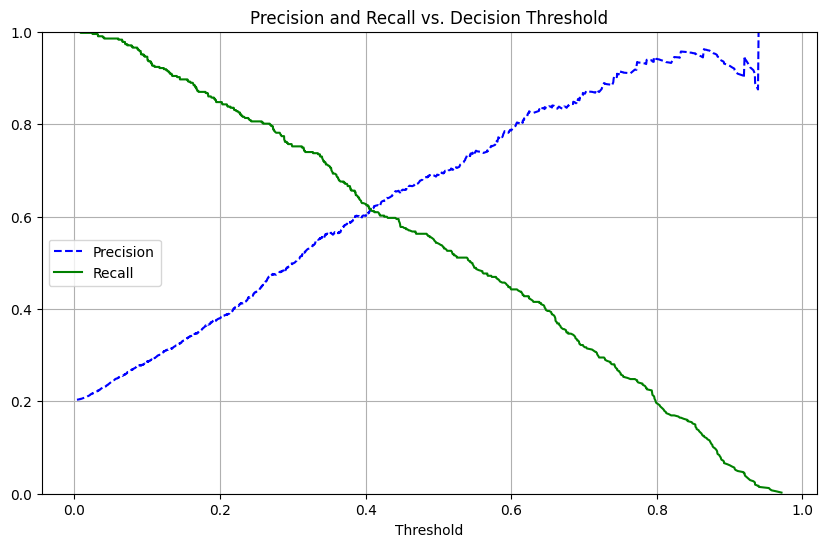


Suggested Optimal Threshold for >= 70% Recall and >= 50% Precision: 0.3529
Corresponding Precision: 0.5632
Corresponding Recall: 0.7002

Classification Report (tuned threshold 0.3529):
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1593
           1       0.56      0.70      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000



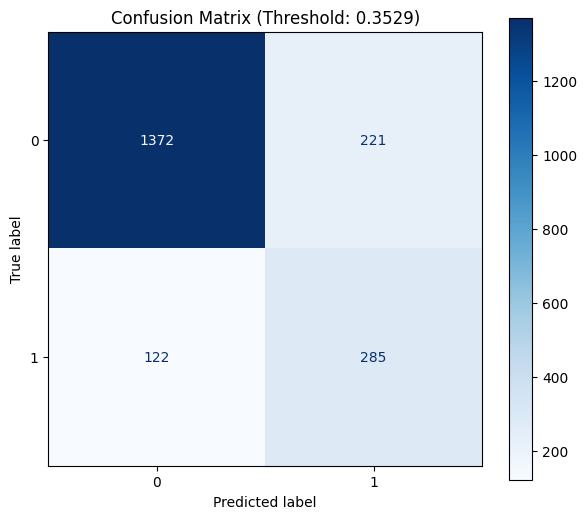

In [76]:
# 1. Generate textual reports
from sklearn.metrics import classification_report, precision_recall_curve

print("Top 10 Feature Importances:")
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
print(importances)
print("\nClassification Report (default 0.5 threshold):")
print(classification_report(y_test, y_pred))

# 2. Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix (Default Threshold)')

# Feature Importance Plot
importances.plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 10 Feature Importances')
axes[1].invert_yaxis()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title('ROC Curve')
axes[2].legend()

plt.tight_layout()
plt.show()

# 3. Precision-Recall-Threshold Curve for Tuning
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

fig_pr, ax_pr = plt.subplots(figsize=(10, 6))
ax_pr.plot(thresholds, precisions[:-1], "b--", label="Precision")
ax_pr.plot(thresholds, recalls[:-1], "g-", label="Recall")
ax_pr.set_xlabel("Threshold")
ax_pr.legend(loc="center left")
ax_pr.set_ylim([0, 1])
ax_pr.set_title('Precision and Recall vs. Decision Threshold')
ax_pr.grid(True)
plt.show()

# Find the threshold that achieves target recall while maintaining a minimum precision
target_recall = 0.70 # Target 70% recall
min_precision = 0.50 # Minimum 50% precision

optimal_threshold = 0.5 # Default if no suitable threshold is found
found_threshold = False

# Iterate from higher thresholds to lower, or from lower to higher depending on how precisions/recalls are indexed
# The precision_recall_curve returns thresholds in ascending order, so we iterate from the end.
# We need to iterate over (precisions, recalls, thresholds) arrays, which typically have 'thresholds' one element shorter.
for i in range(len(thresholds) -1 , -1, -1):
    current_threshold = thresholds[i]
    current_precision = precisions[i]
    current_recall = recalls[i]

    if current_recall >= target_recall and current_precision >= min_precision:
        optimal_threshold = current_threshold
        found_threshold = True
        print(f"\nSuggested Optimal Threshold for >= {target_recall*100:.0f}% Recall and >= {min_precision*100:.0f}% Precision: {optimal_threshold:.4f}")
        print(f"Corresponding Precision: {current_precision:.4f}")
        print(f"Corresponding Recall: {current_recall:.4f}")
        break

if not found_threshold:
    print(f"\nCould not find a threshold that meets both >= {target_recall*100:.0f}% Recall and >= {min_precision*100:.0f}% Precision. Using default 0.5.")
else:
    # Make predictions with the new optimal threshold
    y_pred_tuned = (y_prob >= optimal_threshold).astype(int)
    print(f"\nClassification Report (tuned threshold {optimal_threshold:.4f}):")
    print(classification_report(y_test, y_pred_tuned))

    # Display Confusion Matrix for the tuned threshold
    fig_tuned_cm, ax_tuned_cm = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, ax=ax_tuned_cm, cmap='Blues')
    ax_tuned_cm.set_title(f'Confusion Matrix (Threshold: {optimal_threshold:.4f})')
    plt.show()

In [77]:
# Check class distribution in the original data
print("Original target distribution:")
# Updated from 'y' to 'Exited' for the new dataset
print(df['Exited'].value_counts(normalize=True))

# Check the confusion matrix values more closely (using default threshold predictions)
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix Detail (Default Threshold):")
print(f"True Negatives (Correct No-Churn): {cm[0,0]}")
print(f"False Positives (Predicted Churn, was No-Churn): {cm[0,1]}")
print(f"False Negatives (Missed Churn): {cm[1,0]}")
print(f"True Positives (Correct Churn): {cm[1,1]}")

# Validate that the model isn't just predicting the majority class
unique_preds, counts_preds = np.unique(y_pred, return_counts=True)
print(f"\nModel Prediction Distribution (Default Threshold): {dict(zip(unique_preds, counts_preds))}")

Original target distribution:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Confusion Matrix Detail (Default Threshold):
True Negatives (Correct No-Churn): 1494
False Positives (Predicted Churn, was No-Churn): 99
False Negatives (Missed Churn): 187
True Positives (Correct Churn): 220

Model Prediction Distribution (Default Threshold): {np.int64(0): np.int64(1681), np.int64(1): np.int64(319)}


### Step 6: Model Saving & Inference
Exporting and testing the model.

In [86]:
import numpy as np

joblib.dump(rf_model, 'rf_churn_model.joblib')
loaded_model = joblib.load('rf_churn_model.joblib')

# Select 4 random indices
random_indices = np.random.choice(X_test.index, size=4, replace=False)

# Get corresponding X_test rows and y_test values
X_test_sample = X_test.loc[random_indices]
y_test_sample = y_test.loc[random_indices]

# Make predictions
sample_predictions = loaded_model.predict(X_test_sample)

print("Random Sample Predictions:")
for i in range(len(random_indices)):
    print(f"Row Index: {random_indices[i]}, Predicted: {sample_predictions[i]}, Actual: {y_test_sample.iloc[i]}")

Random Sample Predictions:
Row Index: 398, Predicted: 0, Actual: 0
Row Index: 1828, Predicted: 0, Actual: 0
Row Index: 1720, Predicted: 0, Actual: 0
Row Index: 1059, Predicted: 1, Actual: 1
